# On-Chain Fundamentals: DeFi TVL as Alternative Data

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: See Section 4.4 for alternative data evaluation concepts

## Purpose

Digital assets provide unprecedented transparency: all transactions are public and verifiable.
This "radical transparency" enables analysis of protocol metrics and ecosystem health that
would be impossible in traditional markets. This notebook demonstrates how to source and
analyze **DeFi Total Value Locked (TVL)** as an on-chain fundamental indicator.

## Learning Objectives

After completing this notebook, you will be able to:
- Understand TVL as a fundamental metric for DeFi protocols
- Load real TVL data from DeFi Llama (free, no API key)
- Load ETH prices via CoinGecko (via ml4t-data)
- Calculate on-chain features for trading strategies
- Analyze TVL's relationship with crypto returns

## Data Sources (All Free)

| Source | Metrics | API |
|--------|---------|-----|
| **DeFi Llama** | TVL by chain, protocol, category | `api.llama.fi/` |
| **CoinGecko** | ETH/BTC prices via ml4t-data | `CoinGeckoProvider` |

## Cross-References

- **Upstream**: Free public APIs (no paid data required!)
- **Downstream**: Chapter 8 crypto features, Chapter 12 crypto models
- **Related**: `07_macro_data_alignment.py` (traditional macro alignment)
- **Evaluation**: `11_defi_tvl_evaluation.py` (alt data due diligence)

## Key Concepts

- **TVL (Total Value Locked)**: Assets deposited in DeFi protocols
- **Chain TVL**: Aggregate value locked on a blockchain (Ethereum, Solana, etc.)
- **Protocol TVL**: Value locked in specific protocols (Aave, Uniswap, etc.)
- **TVL/Market Cap**: Valuation ratio for crypto ecosystems

In [1]:
"""On-Chain Fundamentals: DeFi TVL as Alternative Data — source and analyze DeFi TVL for crypto trading signals."""

import warnings

warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_coingecko_ohlcv, load_defillama_chain_tvl

print("On-Chain Fundamentals: DeFi TVL Analysis")

On-Chain Fundamentals: DeFi TVL Analysis


In [2]:
# Production defaults — Papermill injects overrides for CI

---

## Section 1: Understanding DeFi TVL

**Total Value Locked (TVL)** measures the aggregate value of crypto assets deposited
in decentralized finance protocols. It serves as a fundamental metric for:

- **Ecosystem health**: Higher TVL = more capital deployed = stronger ecosystem
- **Protocol adoption**: TVL growth indicates user/capital inflows
- **Yield opportunities**: TVL often correlates with yield farming activity
- **Risk appetite**: TVL drawdowns often precede broader crypto corrections

### Why TVL Matters for Trading — Working Hypotheses

The mapping below is the conventional starting story; Sections 7 and 8
put each hypothesis under empirical scrutiny over the joined window.

| Pattern | Conventional reading |
|---------|----------------------|
| TVL growth > ETH growth | Capital inflows; bullish DeFi sentiment |
| TVL decline + ETH stable | Risk-off; capital exiting DeFi |
| TVL spike | New yield opportunities or protocol launches |
| TVL crash | Exploit, liquidations, or market panic |

---

## Section 2: Load DeFi TVL from DeFi Llama

TVL snapshots come from the canonical downloader, which caches the
DeFi Llama feeds as parquet so this notebook is entirely offline once
the data is on disk:

```bash
python data/crypto/onchain/download.py --dataset defillama
```

The loaders raise `DataNotFoundError` with the exact command if the
file is missing, so there is no hidden network or synthetic-data
fallback — if a chain is not on disk, the reader knows exactly what
to run.

In [3]:
total_tvl = load_defillama_chain_tvl("total").with_columns(
    (pl.col("tvl_usd") / 1e9).alias("tvl_bn")
)
print(f"Total TVL data: {total_tvl.shape}")
print(f"Date range: {total_tvl['timestamp'].min()} → {total_tvl['timestamp'].max()}")
total_tvl.tail(5)

Total TVL data: (3139, 3)
Date range: 2017-09-27 → 2026-05-01


timestamp,tvl_usd,tvl_bn
date,i64,f64
2026-04-27,85237200680,85.237201
2026-04-28,83714613526,83.714614
2026-04-29,83282116410,83.282116
2026-04-30,83484152685,83.484153
2026-05-01,84621565953,84.621566


In [4]:
# Per-chain TVL (Ethereum, Solana, BSC, Arbitrum by default)
chains = ["Ethereum", "Solana", "BSC", "Arbitrum"]
chain_tvls = []
for chain in chains:
    df = load_defillama_chain_tvl(chain).rename({"tvl_usd": f"tvl_{chain.lower()}"})
    chain_tvls.append(df)
    print(f"  {chain}: {len(df):,} observations")

chain_data = chain_tvls[0]
for df in chain_tvls[1:]:
    chain_data = chain_data.join(df, on="timestamp", how="full", coalesce=True)
chain_data = chain_data.sort("timestamp").fill_null(0)
print(f"\nChain TVL data: {chain_data.shape}")
chain_data.tail(5)

  Ethereum: 3,139 observations
  Solana: 1,871 observations
  BSC: 2,009 observations
  Arbitrum: 1,732 observations

Chain TVL data: (3139, 5)


timestamp,tvl_ethereum,tvl_solana,tvl_bsc,tvl_arbitrum
date,i64,i64,i64,i64
2026-04-27,46038137547,5578327139,5581879277,1727267862
2026-04-28,44960729416,5506189186,5505321989,1688346808
2026-04-29,44679406199,5457029022,5490079378,1661010991
2026-04-30,44933870340,5413351730,5459281151,1652285048
2026-05-01,45402955468,5463833233,5472944534,1688898905


---

## Section 3: Load ETH Prices via CoinGecko

We use `ml4t-data`'s CoinGeckoProvider for consistent, reliable price data.

In [5]:
# ETH prices come from the same canonical downloader
# (python data/crypto/onchain/download.py --dataset coingecko).
# Free-tier window is the trailing 365 days — re-run the downloader to
# refresh. For longer history, use a provider with a paid tier.
# CoinGecko's free tier appends a live intraday snapshot for the current
# day on top of that day's 00:00 daily bar, so the final calendar day can
# arrive twice. Collapse to one row per day (keep the most recent snapshot)
# before anything downstream joins or computes on it.
eth_prices = load_coingecko_ohlcv("ethereum").unique(
    subset="timestamp", keep="last", maintain_order=True
)
print(f"ETH prices: {eth_prices.shape}")
print(f"Window: {eth_prices['timestamp'].min()} → {eth_prices['timestamp'].max()}")

ETH prices: (365, 3)
Window: 2025-05-02 → 2026-05-01


---

## Section 4: Merge TVL and Price Data

The CoinGecko free-tier window of 365 trailing days bounds the joined
dataset. The TVL series itself goes back to 2017 — substituting a paid
price feed (or the longer Binance / Kraken history loaded in
`02_crypto_perps_funding`) extends the analysis to the full TVL history.

In [6]:
combined = (
    total_tvl.join(
        eth_prices.rename({"price_usd": "eth_price", "volume_usd": "eth_volume"}),
        on="timestamp",
        how="inner",
    )
    .join(
        chain_data.with_columns(pl.col("timestamp").cast(pl.Date)),
        on="timestamp",
        how="left",
    )
    .fill_null(strategy="forward")
)

print(f"Combined dataset: {combined.shape}, columns: {combined.columns}")
combined.tail(5)

Combined dataset: (365, 9), columns: ['timestamp', 'tvl_usd', 'tvl_bn', 'eth_price', 'eth_volume', 'tvl_ethereum', 'tvl_solana', 'tvl_bsc', 'tvl_arbitrum']


timestamp,tvl_usd,tvl_bn,eth_price,eth_volume,tvl_ethereum,tvl_solana,tvl_bsc,tvl_arbitrum
date,i64,f64,f64,f64,i64,i64,i64,i64
2026-04-27,85237200680,85.237201,2369.743029,1.1012e10,46038137547,5578327139,5581879277,1727267862
2026-04-28,83714613526,83.714614,2299.770459,1.2151e10,44960729416,5506189186,5505321989,1688346808
2026-04-29,83282116410,83.282116,2288.044927,1.2067e10,44679406199,5457029022,5490079378,1661010991
2026-04-30,83484152685,83.484153,2253.458358,1.9379e10,44933870340,5413351730,5459281151,1652285048
2026-05-01,84621565953,84.621566,2294.157168,1.2321e10,45402955468,5463833233,5472944534,1688898905


---

## Section 5: Visualize TVL and ETH Price Relationship

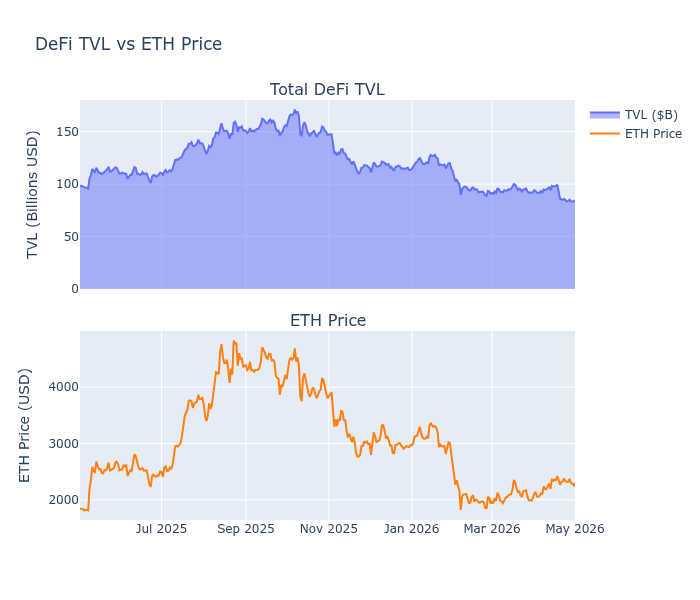

In [7]:
# Plot TVL vs ETH price
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Total DeFi TVL", "ETH Price"),
    row_heights=[0.5, 0.5],
)

fig.add_trace(
    go.Scatter(x=combined["timestamp"], y=combined["tvl_bn"], name="TVL ($B)", fill="tozeroy"),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=combined["timestamp"],
        y=combined["eth_price"],
        name="ETH Price",
        line=dict(color="#ff7f0e"),
    ),
    row=2,
    col=1,
)

fig.update_layout(title="DeFi TVL vs ETH Price", height=600, showlegend=True)
fig.update_yaxes(title_text="TVL (Billions USD)", row=1, col=1)
fig.update_yaxes(title_text="ETH Price (USD)", row=2, col=1)
fig.show()

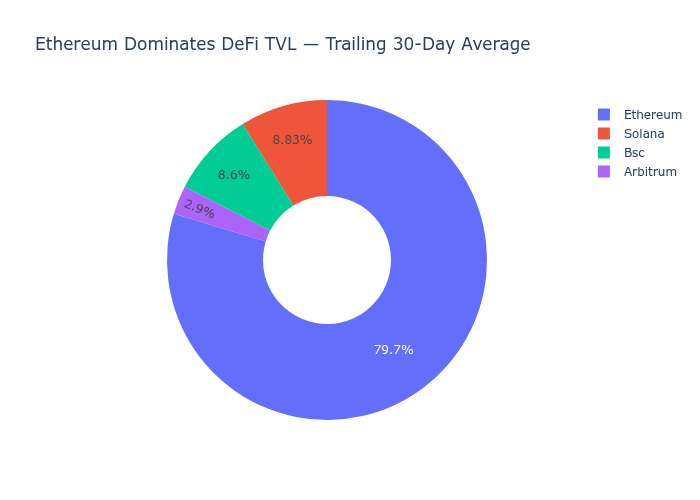

In [8]:
chain_cols = [
    c for c in combined.columns if c.startswith("tvl_") and c not in {"tvl_bn", "tvl_usd"}
]
recent = combined.filter(pl.col("timestamp") > pl.col("timestamp").max() - pl.duration(days=30))
chain_totals = {col.replace("tvl_", "").title(): recent[col].mean() / 1e9 for col in chain_cols}

fig = go.Figure(
    data=[
        go.Pie(
            labels=list(chain_totals.keys()),
            values=list(chain_totals.values()),
            hole=0.4,
        )
    ]
)
fig.update_layout(title="Ethereum Dominates DeFi TVL — Trailing 30-Day Average")
fig.show()

---

## Section 6: Create On-Chain Trading Features

In [9]:
def create_tvl_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute TVL momentum, valuation, and regime features."""
    return df.with_columns(
        pl.col("tvl_bn").pct_change(7).alias("tvl_growth_7d"),
        pl.col("tvl_bn").pct_change(30).alias("tvl_growth_30d"),
        pl.col("tvl_bn").pct_change(90).alias("tvl_growth_90d"),
        pl.col("tvl_bn").rolling_mean(7).alias("tvl_ma7"),
        pl.col("tvl_bn").rolling_mean(30).alias("tvl_ma30"),
        (
            (pl.col("tvl_bn") - pl.col("tvl_bn").rolling_mean(90))
            / pl.col("tvl_bn").rolling_std(90)
        ).alias("tvl_zscore"),
        pl.col("eth_price").pct_change(7).alias("eth_return_7d"),
        pl.col("eth_price").pct_change(30).alias("eth_return_30d"),
    ).with_columns(
        (pl.col("tvl_bn") / pl.col("eth_price")).alias("tvl_price_ratio"),
        (pl.col("tvl_growth_30d") - pl.col("eth_return_30d")).alias("tvl_eth_spread"),
        # Warm-up rows without a valid 90-day z-score stay null (unclassified),
        # never fall through to "neutral"; the regime aggregation excludes them.
        pl.when(pl.col("tvl_zscore").is_null())
        .then(pl.lit(None, dtype=pl.String))
        .when(pl.col("tvl_zscore") > 1.0)
        .then(pl.lit("expansion"))
        .when(pl.col("tvl_zscore") < -1.0)
        .then(pl.lit("contraction"))
        .otherwise(pl.lit("neutral"))
        .alias("tvl_regime"),
    )


features = create_tvl_features(combined)
print(f"Features created: {len(features.columns)} columns")

features.select(
    "timestamp",
    "tvl_bn",
    "eth_price",
    "tvl_growth_30d",
    "eth_return_30d",
    "tvl_eth_spread",
    "tvl_regime",
).tail(10)

Features created: 20 columns


timestamp,tvl_bn,eth_price,tvl_growth_30d,eth_return_30d,tvl_eth_spread,tvl_regime
date,f64,f64,f64,f64,f64,str
2026-04-22,85.071924,2327.511633,-0.080184,0.133632,-0.213816,"""contraction"""
2026-04-23,85.864574,2377.934397,-0.09543,0.105246,-0.200676,"""contraction"""
2026-04-24,84.493345,2330.827582,-0.112082,0.081248,-0.193331,"""contraction"""
2026-04-25,83.553774,2315.512435,-0.12933,0.067913,-0.197243,"""contraction"""
2026-04-26,84.044109,2319.150324,-0.099584,0.126166,-0.22575,"""contraction"""
2026-04-27,85.237201,2369.743029,-0.070388,0.18969,-0.260078,"""contraction"""
2026-04-28,83.714614,2299.770459,-0.089589,0.154058,-0.243647,"""contraction"""
2026-04-29,83.282116,2288.044927,-0.094527,0.153723,-0.24825,"""contraction"""
2026-04-30,83.484153,2253.458358,-0.093046,0.113466,-0.206511,"""contraction"""


---

## Section 7: Analyze TVL as a Trading Signal

Does TVL momentum predict future ETH returns?

In [10]:
# Calculate forward returns
analysis = features.with_columns(
    [
        pl.col("eth_return_30d").shift(-30).alias("fwd_eth_return_30d"),
        pl.col("eth_return_7d").shift(-7).alias("fwd_eth_return_7d"),
    ]
).filter(pl.col("fwd_eth_return_30d").is_not_null())

# Regime analysis
regime_returns = (
    analysis.filter(pl.col("tvl_regime").is_not_null())
    .group_by("tvl_regime")
    .agg(
        pl.col("fwd_eth_return_30d").mean().alias("avg_fwd_return"),
        pl.col("fwd_eth_return_30d").std().alias("std_fwd_return"),
        pl.len().alias("n_obs"),
        (pl.col("fwd_eth_return_30d") > 0).mean().alias("win_rate"),
    )
    .sort("avg_fwd_return", descending=True)
)

regime_returns

tvl_regime,avg_fwd_return,std_fwd_return,n_obs,win_rate
str,f64,f64,u32,f64
"""contraction""",0.012603,0.082799,97,0.515464
"""expansion""",-0.023619,0.133068,64,0.484375
"""neutral""",-0.163669,0.179557,85,0.258824


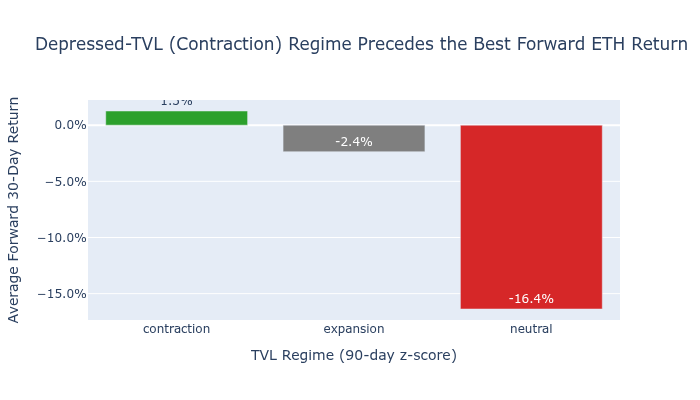

In [11]:
# Visualize regime returns
fig = go.Figure(
    data=[
        go.Bar(
            x=regime_returns["tvl_regime"],
            y=regime_returns["avg_fwd_return"],
            text=[f"{r:.1%}" if r is not None else "N/A" for r in regime_returns["avg_fwd_return"]],
            textposition="auto",
            marker_color=["#2ca02c", "#7f7f7f", "#d62728"],
        )
    ]
)

fig.update_layout(
    title="Depressed-TVL (Contraction) Regime Precedes the Best Forward ETH Return",
    xaxis_title="TVL Regime (90-day z-score)",
    yaxis_title="Average Forward 30-Day Return",
    yaxis_tickformat=".1%",
    height=400,
)
fig.show()

The empirical regime ranking cuts against the naive narrative in
Section 1. Only rows with a valid 90-day z-score enter the table, so the
first ~90 warm-up days (no z-score yet) are excluded rather than pooled
into the neutral band. Over the trailing year on disk, the **contraction**
regime, TVL more than one standard deviation *below* its 90-day mean,
precedes the best average forward 30-day ETH return; the stretched
**expansion** regime (more than one standard deviation above the mean)
precedes a negative return; and the **neutral** middle band trails both.
Two readings are consistent with this:

1. **Mean-reversion in TVL.** A depressed z-score marks capital that has
   already left DeFi and tends to rebuild, so it precedes recovery,
   whereas a stretched z-score above +1 is more likely to revert than to
   extend and drags forward returns with it.
2. **Sample-window dependence.** The CoinGecko free-tier window covers a
   single 365-day slice with overlapping 30-day forward horizons, so the
   regime buckets are far from independent; longer histories with paid
   feeds are needed before this pattern can be treated as a stable signal.

Either way, the qualitative table in Section 1 ("TVL growth → bullish")
is a starting hypothesis, not a verified result, and the IC analysis in
the next cell quantifies the linear version of this relationship.

In [12]:
ic = (
    analysis.filter(
        pl.col("tvl_growth_30d").is_not_null() & pl.col("fwd_eth_return_30d").is_not_null()
    )
    .select(pl.corr("tvl_growth_30d", "fwd_eth_return_30d"))
    .item()
)
band = "moderate" if abs(ic) > 0.1 else "weak" if abs(ic) > 0.05 else "negligible"
print(f"IC(TVL growth → forward 30d ETH return) = {ic:+.3f}  ({band} linear signal)")

IC(TVL growth → forward 30d ETH return) = +0.066  (weak linear signal)


---

## Section 8: Summary Statistics

A compact summary of TVL level, dispersion, and recent dynamics over the
joined window, plus the latest reading.

In [13]:
features.select(
    pl.col("tvl_bn").min().round(1).alias("tvl_min_bn"),
    pl.col("tvl_bn").max().round(1).alias("tvl_max_bn"),
    pl.col("tvl_bn").mean().round(1).alias("tvl_mean_bn"),
    pl.col("tvl_bn").std().round(1).alias("tvl_std_bn"),
    (pl.col("tvl_growth_30d").mean() * 100).round(2).alias("avg_30d_growth_pct"),
    (pl.col("tvl_eth_spread").mean() * 100).round(2).alias("avg_tvl_eth_spread_pct"),
)

tvl_min_bn,tvl_max_bn,tvl_mean_bn,tvl_std_bn,avg_30d_growth_pct,avg_tvl_eth_spread_pct
f64,f64,f64,f64,f64,f64
83.3,171.2,120.5,22.6,-0.73,-2.68


In [14]:
features.tail(1).select(
    "timestamp",
    pl.col("tvl_bn").round(1).alias("tvl_bn"),
    pl.col("eth_price").round(0).alias("eth_price"),
    "tvl_regime",
)

timestamp,tvl_bn,eth_price,tvl_regime
date,f64,f64,str
2026-05-01,84.6,2294.0,"""contraction"""


---

## Key Takeaways

1. **DeFi Llama supplies a free, multi-year TVL panel.** The total
   series spans 2017-09-27 to the current date; per-chain coverage
   starts at each chain's launch (Solana 2021, Arbitrum 2021, BSC 2020).
2. **The price feed is the binding constraint.** CoinGecko's free tier
   caps history at 365 days, so the joined panel reduces to one
   trailing year. Longer studies require a paid feed or an exchange
   OHLCV history.
3. **Ethereum still dominates trailing-30-day chain TVL share**, with
   Solana, BSC, and Arbitrum sharing the remainder.
4. **Naive "expansion = bullish" framing is empirically backwards over
   this window.** Among rows with a valid 90-day z-score, the depressed
   -1σ contraction regime precedes the best forward 30-day ETH return
   while the stretched +1σ expansion regime precedes a negative one; the
   linear IC of TVL growth vs forward returns is small and positive
   (about +0.07). Treat the regime table in Section 1 as a hypothesis
   template, not a verified rule.
5. **TVL belongs in the feature set, not the conclusion.** It is one
   cross-asset signal — combine with price-based momentum, funding,
   and macro features before drawing trading conclusions.

## Next Steps

- `11_defi_tvl_evaluation.py` — formal alpha/decay/cost evaluation of
  TVL signals, mapped to the Chapter 4 alt-data framework.
- Chapter 8 — feature engineering for crypto including on-chain
  composite scores.
- Chapter 12 — gradient-boosted models that ingest TVL features for
  crypto trading.